In [1]:
from layout_module import Layout, NestedTuple, plot_layout, Swizzle, ComposedLayout, make_composed

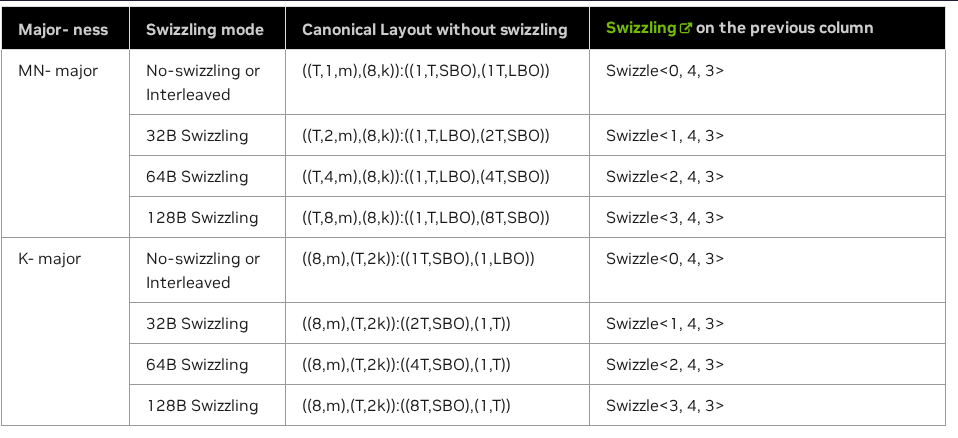

In [2]:
from typing import Literal

def make_layout(
    element_bytes: int,
    m: int,
    k: int,
    LBO: int,
    SBO: int,
    is_k_major: bool,
    swizzle_bytes: Literal[0, 32, 64, 128],
):
    T = 16 // element_bytes

    if is_k_major:
        if swizzle_bytes == 0:
            shape = ((8, m), (T, 2 * k))
            stride = ((1 * T, SBO), (1, LBO))
        elif swizzle_bytes == 32:
            shape = ((8, m), (T, 2 * k))
            stride = ((2 * T, SBO), (1, T))
        elif swizzle_bytes == 64:
            shape = ((8, m), (T, 2 * k))
            stride = ((4 * T, SBO), (1, T))
        elif swizzle_bytes == 128:
            shape = ((8, m), (T, 2 * k))
            stride = ((8 * T, SBO), (1, T))
        else:
            raise ValueError(f"invalid swizzle_bytes: {swizzle_bytes}")
    else:
        if swizzle_bytes == 0:
            shape = ((T, 1, m), (8, k))
            stride = ((1, T, SBO), (1 * T, LBO))
        elif swizzle_bytes == 32:
            shape = ((T, 2, m), (8, k))
            stride = ((1, T, LBO), (2 * T, SBO))
        elif swizzle_bytes == 64:
            shape = ((T, 4, m), (8, k))
            stride = ((1, T, LBO), (4 * T, SBO))
        elif swizzle_bytes == 128:
            shape = ((T, 8, m), (8, k))
            stride = ((1, T, LBO), (8 * T, SBO))
        else:
            raise ValueError(f"invalid swizzle_bytes: {swizzle_bytes}")

    return shape, stride 
  

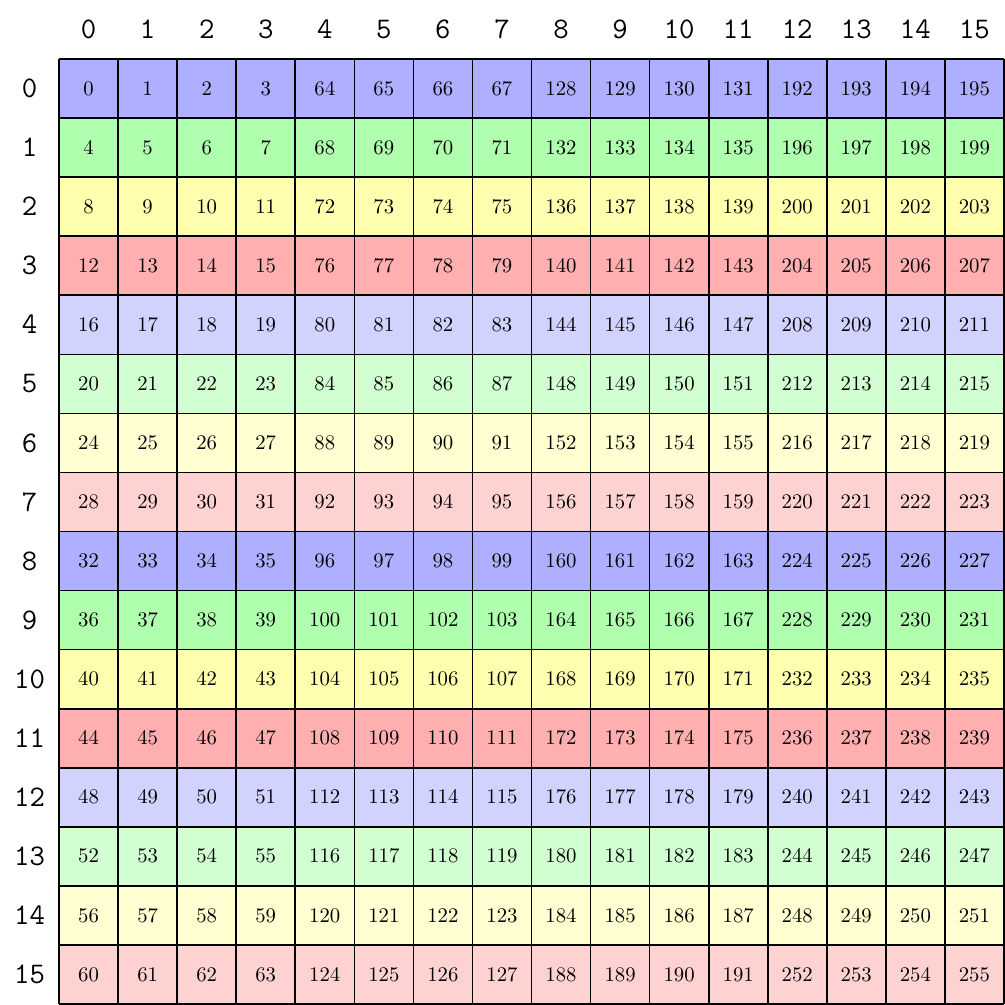

In [8]:
block_M = 16 
element_size_bytes = 4
block_K_BYTES = (16*element_size_bytes) 
LBO = block_M*16 
SBO = 128 
m = block_M//8 
k = block_K_BYTES//32
swizzle_bytes = 0 
shape,stride = make_layout(element_size_bytes, m,k,LBO//4, SBO//4, True, 0)

In [9]:
L = Layout(NestedTuple.from_literal(shape), NestedTuple.from_literal(stride))

<Axes: title={'center': '((8,2),(4,4)) : ((4,32),(1,64))'}, xlabel='mode 1', ylabel='mode 0'>

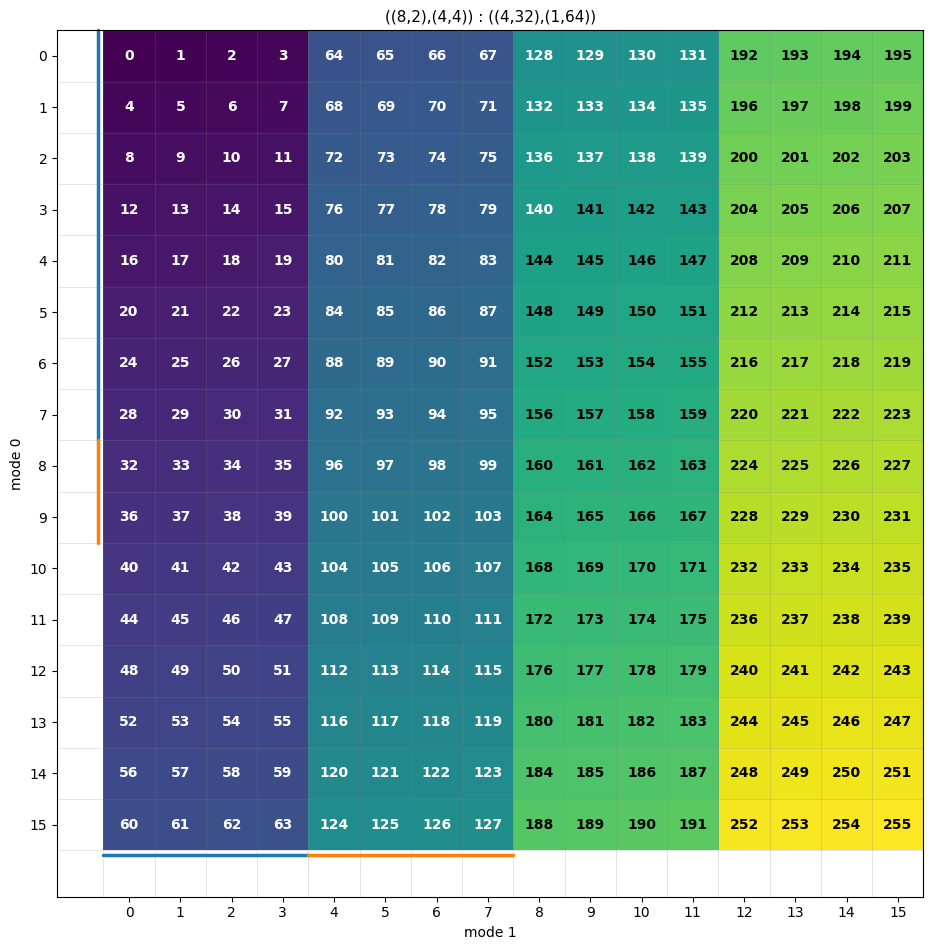

In [10]:
plot_layout(L)

In [11]:
swizzle = Swizzle(0,4,3,4)
L_swiz = make_composed(L, swizzle)

<Axes: title={'center': '((8,2),(4,4)) : ((4,32),(1,64))'}, xlabel='mode 1', ylabel='mode 0'>

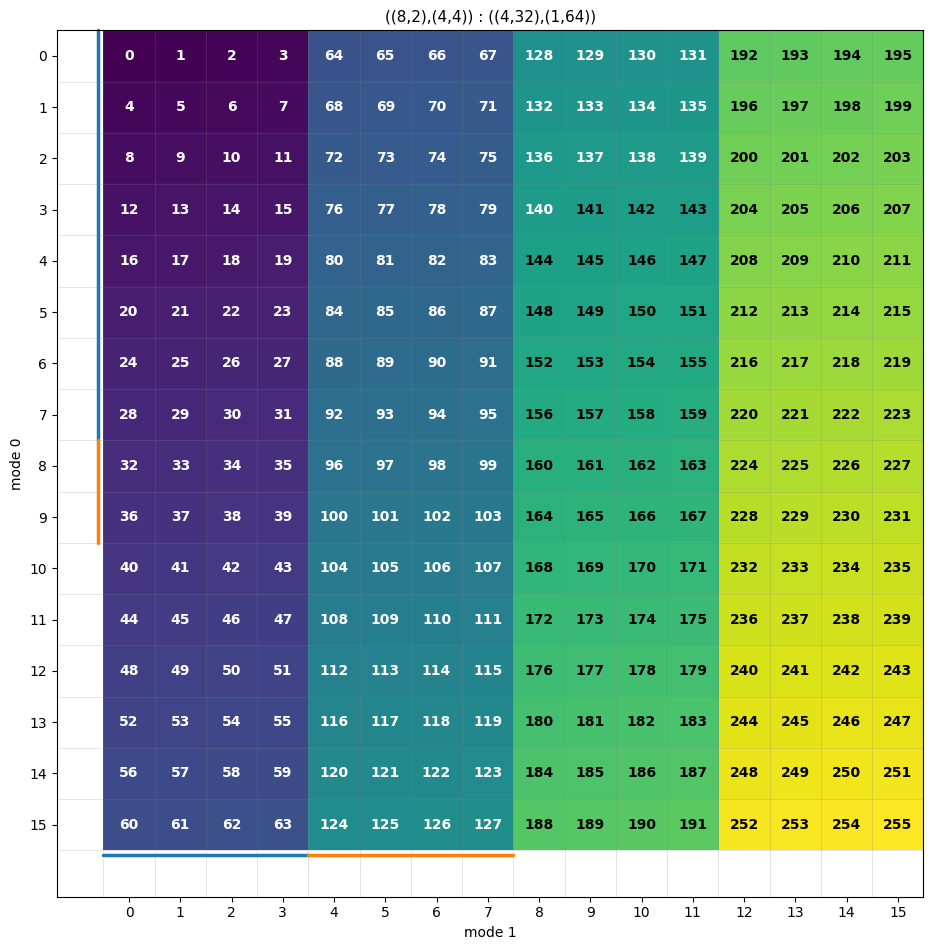

In [12]:
plot_layout(L_swiz)